# Exoplanet Classification

## Overview
This project classifies exoplanets using supervised machine learning techniques.

## Tasks Performed
- Loaded the exoplanet dataset
- Performed exploratory data analysis
- Cleaned and preprocessed data
- Selected important features
- Trained classification models
- Evaluated model performance

## Libraries Used
- Pandas
- NumPy
- Scikit-learn

## Goal
Classify exoplanets based on their observed characteristics.

In [1]:
import pandas as pd 


In [3]:
df = pd.read_csv("cumulative.csv")

In [4]:
df.head()

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,-81.0,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347
2,3,10811496,K00753.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-176.0,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,-174.0,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,-211.0,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509


In [5]:
df.shape

(9564, 50)

In [6]:
df.describe()

,rowid,kepid,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_period,koi_period_err1,koi_period_err2,...,koi_steff_err2,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag
count,9564.000000,9.564000e+03,8054.000000,9564.000000,9564.000000,9564.000000,9564.000000,9564.000000,9110.000000,9110.000000,...,9081.000000,9201.000000,9096.000000,9096.000000,9201.000000,9096.000000,9096.000000,9564.000000,9564.000000,9563.000000
mean,4782.500000,7.690628e+06,0.480829,0.188206,0.231598,0.194898,0.120033,75.671358,0.002148,-0.002148,...,-162.265059,4.310157,0.120738,-0.143161,1.728712,0.362292,-0.394806,292.060163,43.810433,14.264606
std,2761.033321,2.653459e+06,0.476928,0.390897,0.421875,0.396143,0.325018,1334.744046,0.008236,0.008236,...,72.746348,0.432606,0.132837,0.085477,6.127185,0.930870,2.168213,4.766657,3.601243,1.385448
min,1.000000,7.574500e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.241843,0.000000,-0.172500,...,-1762.000000,0.047000,0.000000,-1.207000,0.109000,0.000000,-116.137000,279.852720,36.577381,6.966000
25%,2391.750000,5.556034e+06,0.000000,0.000000,0.000000,0.000000,0.000000,2.733684,0.000005,-0.000276,...,-198.000000,4.218000,0.042000,-0.196000,0.829000,0.129000,-0.250000,288.660770,40.777173,13.440000
50%,4782.500000,7.906892e+06,0.334000,0.000000,0.000000,0.000000,0.000000,9.752831,0.000035,-0.000035,...,-160.000000,4.438000,0.070000,-0.128000,1.000000,0.251000,-0.111000,292.261125,43.677504,14.520000
75%,7173.250000,9.873066e+06,0.998000,0.000000,0.000000,0.000000,0.000000,40.715178,0.000276,-0.000005,...,-114.000000,4.543000,0.149000,-0.088000,1.345000,0.364000,-0.069000,295.859160,46.714611,15.322000
max,9564.000000,1.293514e+07,1.000000,1.000000,1.000000,1.000000,1.000000,129995.778400,0.172500,0.000000,...,0.000000,5.364000,1.472000,0.000000,229.908000,33.091000,0.000000,301.720760,52.336010,20.003000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 50 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rowid              9564 non-null   int64  
 1   kepid              9564 non-null   int64  
 2   kepoi_name         9564 non-null   object 
 3   kepler_name        2294 non-null   object 
 4   koi_disposition    9564 non-null   object 
 5   koi_pdisposition   9564 non-null   object 
 6   koi_score          8054 non-null   float64
 7   koi_fpflag_nt      9564 non-null   int64  
 8   koi_fpflag_ss      9564 non-null   int64  
 9   koi_fpflag_co      9564 non-null   int64  
 10  koi_fpflag_ec      9564 non-null   int64  
 11  koi_period         9564 non-null   float64
 12  koi_period_err1    9110 non-null   float64
 13  koi_period_err2    9110 non-null   float64
 14  koi_time0bk        9564 non-null   float64
 15  koi_time0bk_err1   9110 non-null   float64
 16  koi_time0bk_err2   9110 

In [8]:
df.isnull().sum()

rowid                   0
kepid                   0
kepoi_name              0
kepler_name          7270
koi_disposition         0
koi_pdisposition        0
koi_score            1510
koi_fpflag_nt           0
koi_fpflag_ss           0
koi_fpflag_co           0
koi_fpflag_ec           0
koi_period              0
koi_period_err1       454
koi_period_err2       454
koi_time0bk             0
koi_time0bk_err1      454
koi_time0bk_err2      454
koi_impact            363
koi_impact_err1       454
koi_impact_err2       454
koi_duration            0
koi_duration_err1     454
koi_duration_err2     454
koi_depth             363
koi_depth_err1        454
koi_depth_err2        454
koi_prad              363
koi_prad_err1         363
koi_prad_err2         363
koi_teq               363
koi_teq_err1         9564
koi_teq_err2         9564
koi_insol             321
koi_insol_err1        321
koi_insol_err2        321
koi_model_snr         363
koi_tce_plnt_num      346
koi_tce_delivname     346
koi_steff   

In [10]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.nunique()

rowid                9564
kepid                8214
kepoi_name           9564
kepler_name          2294
koi_disposition         3
koi_pdisposition        2
koi_score             650
koi_fpflag_nt           2
koi_fpflag_ss           2
koi_fpflag_co           2
koi_fpflag_ec           2
koi_period           9564
koi_period_err1      7448
koi_period_err2      7448
koi_time0bk          9538
koi_time0bk_err1     2530
koi_time0bk_err2     2530
koi_impact           2406
koi_impact_err1      2217
koi_impact_err2      1884
koi_duration         7834
koi_duration_err1    2264
koi_duration_err2    2264
koi_depth            6947
koi_depth_err1       1428
koi_depth_err2       1428
koi_prad             2988
koi_prad_err1        1787
koi_prad_err2        1561
koi_teq              2511
koi_teq_err1            0
koi_teq_err2            0
koi_insol            7801
koi_insol_err1       7130
koi_insol_err2       6560
koi_model_snr        2740
koi_tce_plnt_num        8
koi_tce_delivname       3
koi_steff   

In [13]:
columns_to_drop = [
    'rowid', 'kepid', 'kepoi_name', 'kepler_name', 
    'koi_teq_err1', 'koi_teq_err2', 'koi_tce_delivname'
]

In [14]:
df_clean = df.drop(columns=columns_to_drop)

In [15]:
X = df_clean.drop(columns=['koi_disposition', 'koi_pdisposition'])


In [16]:
y = df_clean['koi_disposition']

In [17]:
from sklearn.preprocessing import LabelEncoder

In [18]:
label_encoder = LabelEncoder()

In [20]:
y_encoded = label_encoder.fit_transform(y)

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [23]:
from sklearn.impute import SimpleImputer

In [24]:
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X.columns)

In [25]:
print(f"Train set shape: {X_train_imputed.shape}, Test set shape: {X_test_imputed.shape}")

Train set shape: (7651, 41), Test set shape: (1913, 41)


In [26]:
from sklearn.ensemble import RandomForestClassifier

In [27]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [28]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_imputed, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
y_pred = rf_model.predict(X_test_imputed)

In [30]:
y_pred

array([2, 0, 0, ..., 2, 2, 2], shape=(1913,))

In [31]:
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

                precision    recall  f1-score   support

     CANDIDATE       0.82      0.80      0.81       449
     CONFIRMED       0.83      0.85      0.84       459
FALSE POSITIVE       0.98      0.99      0.98      1005

      accuracy                           0.91      1913
     macro avg       0.88      0.88      0.88      1913
  weighted avg       0.91      0.91      0.91      1913



In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\harsh\AppData\Local\Temp\ipykernel_6476\3565944185.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


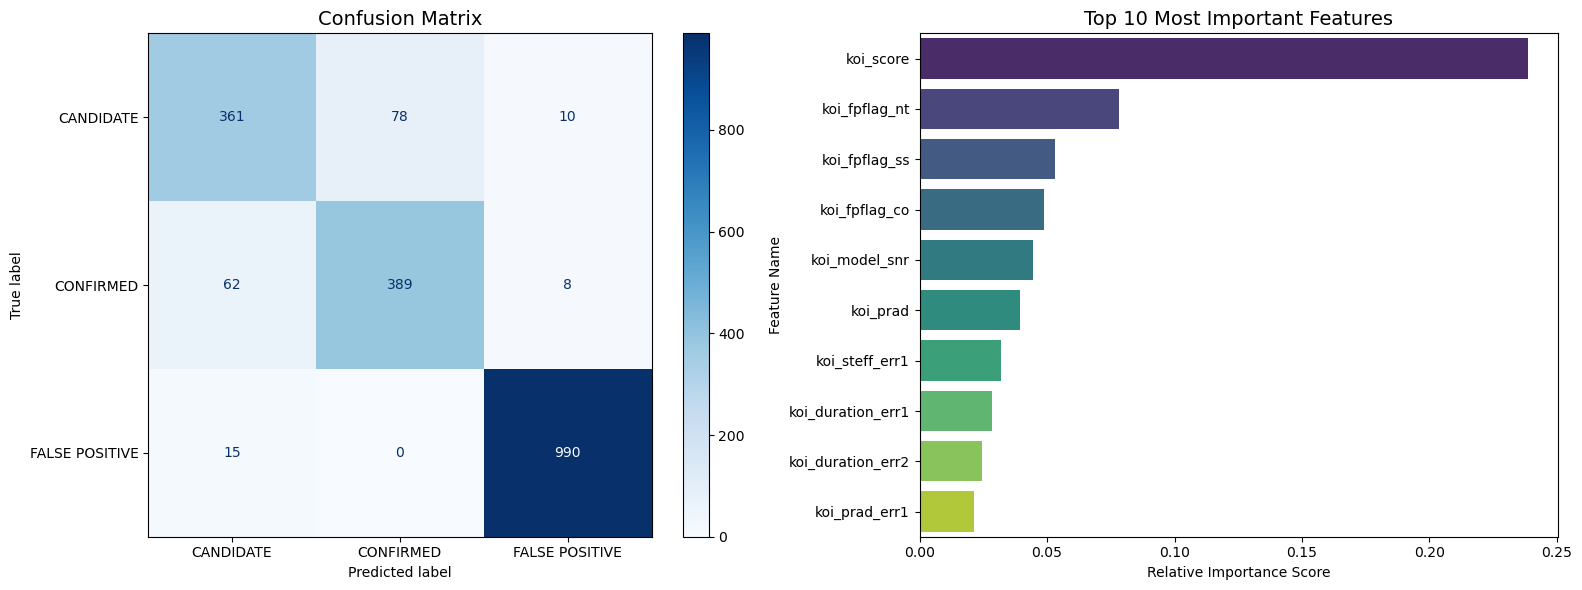

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, 
    display_labels=label_encoder.classes_, 
    cmap='Blues', 
    ax=axes[0]
)
axes[0].set_title("Confusion Matrix", fontsize=14)
axes[0].grid(False)

importances = rf_model.feature_importances_
rf_importances = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
top_10_features = rf_importances.sort_values(by='Importance', ascending=False).head(10)

sns.barplot(
    data=top_10_features, 
    x='Importance', 
    y='Feature', 
    palette='viridis', 
    ax=axes[1]
)
axes[1].set_title("Top 10 Most Important Features", fontsize=14)
axes[1].set_xlabel("Relative Importance Score")
axes[1].set_ylabel("Feature Name")

plt.tight_layout()
plt.show()

In [36]:
import joblib

In [37]:
joblib.dump(rf_model, 'kepler_exoplanet_model.pkl')
joblib.dump(label_encoder, 'label_encoder.pkl')
print("Model saved successfully!")

Model saved successfully!
